# Problem Statement: Build a model which predicts whether machine will fail or not

# Step1: Data Gathering

In [1]:
import pandas as pd
path = r"C:\Users\SAMRUDHI\OneDrive\Desktop\DATA SCIENCE\Datasets\Machine Failure Prediction\train.csv"
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [2]:
df['Machine failure'].unique()

array([0, 1])

    0 - Machine is Not Failed
    1 - Machine is Failed

In [3]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

In [4]:
(df['Machine failure'].value_counts()/len(df))*100

Machine failure
0    98.425555
1     1.574445
Name: count, dtype: float64

<Axes: ylabel='Machine failure'>

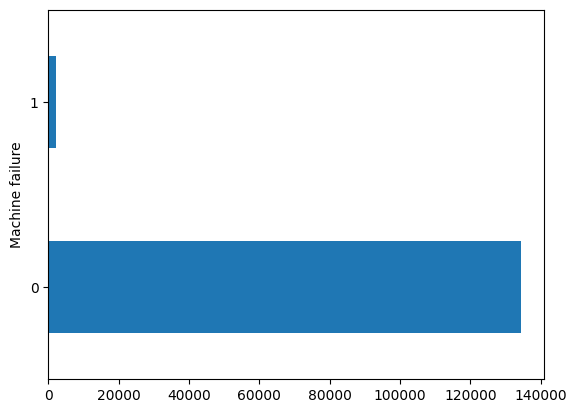

In [7]:
import matplotlib.pyplot as plt
df['Machine failure'].value_counts().plot(kind='barh')

## The above data provided by client is imbalanced data

# Step 2: Perform the basic data quality checks 

In [8]:
df.shape

(136429, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [10]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

In [11]:
# drop duplicates
df = df.drop_duplicates()

In [12]:
# check for missing values
df.isna().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

# Step3: Separate X and Y features
    X = All the features except Machine Failure
    Y = Machine Failure

In [13]:
X = df.drop(columns=['id','Product ID','Machine failure'])
Y = df[['Machine failure']]

In [14]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0


In [16]:
Y.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


# Step4 : Data Cleaning and Data Preprocessing(Feature Scaling)

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns)
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform='pandas')

X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,1.0,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,1.0,0.0,0.610675,0.692284,0.026445,0.464745,1.447532,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


# Step5 : Splitting the data into training and testing

In [20]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=21)

In [21]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(102321, 13)
(34108, 13)
(102321, 1)
(34108, 1)


# SMOTE: Increasing the samples of minority class

In [22]:
ytrain['Machine failure'].value_counts()

Machine failure
0    100713
1      1608
Name: count, dtype: int64

In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_sampl,y_sampl = smote.fit_resample(xtrain,ytrain)

In [25]:
y_sampl['Machine failure'].value_counts()

Machine failure
0    100713
1    100713
Name: count, dtype: int64

# Step6: Model Building 

In [26]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(x_sampl,y_sampl)

c:\Users\SAMRUDHI\OneDrive\Desktop\DATA SCIENCE\Machine Learning\repository\Machine Failure Prediction Project --Classification\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=3,
    min_samples_split=3
)

model2.fit(x_sampl,y_sampl)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10
)

model3.fit(x_sampl,y_sampl)

c:\Users\SAMRUDHI\OneDrive\Desktop\DATA SCIENCE\Machine Learning\repository\Machine Failure Prediction Project --Classification\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluation Of Model


================ Logistic Regression ================
Accuracy: 0.9770728274891521
Precision: 0.39177101967799643
Recall: 0.8111111111111111
F1 Score: 0.5283474065138721
ROC-AUC: 0.9346119706157541

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     33568
           1       0.39      0.81      0.53       540

    accuracy                           0.98     34108
   macro avg       0.69      0.90      0.76     34108
weighted avg       0.99      0.98      0.98     34108



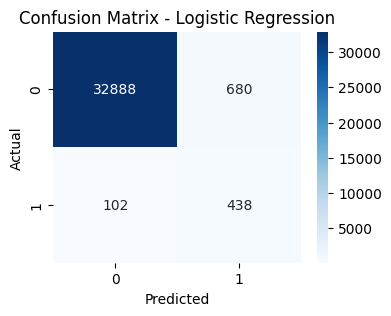


================ Decision Tree ================
Accuracy: 0.9779230679019585
Precision: 0.40148011100832565
Recall: 0.8037037037037037
F1 Score: 0.5354719309068476
ROC-AUC: 0.9216237686685732

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     33568
           1       0.40      0.80      0.54       540

    accuracy                           0.98     34108
   macro avg       0.70      0.89      0.76     34108
weighted avg       0.99      0.98      0.98     34108



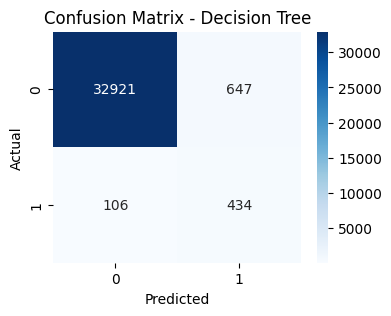


================ Random Forest ================
Accuracy: 0.9682772370118448
Precision: 0.31258644536652835
Recall: 0.837037037037037
F1 Score: 0.4551863041289023
ROC-AUC: 0.9593454028086714

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     33568
           1       0.31      0.84      0.46       540

    accuracy                           0.97     34108
   macro avg       0.65      0.90      0.72     34108
weighted avg       0.99      0.97      0.98     34108



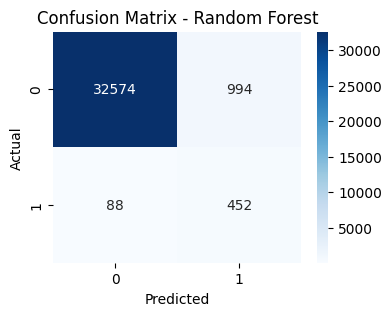

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

models = [
    ("Logistic Regression", model1),
    ("Decision Tree", model2),
    ("Random Forest", model3),
    ##("SVM", model4) -- As SVM is not fitting because of large dataset
]

evaluation_results = []

for name, model in models:
    
    print(f"\n================ {name} ================")
    
    # Predictions
    y_pred = model.predict(xtest)
    y_pred_proba = model.predict_proba(xtest)[:,1]
    
    # Metrics
    acc = accuracy_score(ytest, y_pred)
    prec = precision_score(ytest, y_pred)
    rec = recall_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)
    auc_score = roc_auc_score(ytest, y_pred_proba)
    
    evaluation_results.append([name, acc, prec, rec, f1, auc_score])
    
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc_score)
    
    print("\nClassification Report:")
    print(classification_report(ytest, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(ytest, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [33]:
results_df = pd.DataFrame(
    evaluation_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.968277,0.312586,0.837037,0.455186,0.959345
0,Logistic Regression,0.977073,0.391771,0.811111,0.528347,0.934612
1,Decision Tree,0.977923,0.401480,0.803704,0.535472,0.921624


In [34]:
# pip install joblib
import joblib

# save the pipeline - data preprocessing and cleaning
joblib.dump(pre,'pre.joblib')

# save the model 
joblib.dump(model,'model.joblib')

['model.joblib']

In [35]:
model_load = joblib.load('model.joblib')
pre_load = joblib.load('pre.joblib')

# Check on unseen data

In [36]:
path2 = r"C:\Users\SAMRUDHI\OneDrive\Desktop\DATA SCIENCE\Datasets\Machine Failure Prediction\test.csv"
xnew = pd.read_csv(path2)
xnew

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0
1,1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0
2,2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0
3,3,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0
4,4,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0
9996,9996,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0
9997,9997,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0
9998,9998,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0


In [37]:
xnew.isna().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [38]:
xnew.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [39]:
xnew_pre = pre_load.transform(xnew)
xnew_pre

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,0.0,1.0,-0.946589,-0.968164,0.221059,0.288320,-1.632287,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,1.0,0.0,-0.892890,-0.895971,-0.809675,0.699979,-1.585386,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,-0.946589,-1.040358,-0.160961,1.064590,-1.554119,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,1.0,0.0,-0.892890,-0.968164,-0.629476,-0.099815,-1.522852,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,1.0,0.0,-0.892890,-0.895971,-0.809675,-0.041006,-1.491584,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,-0.570697,-1.112551,0.603079,-1.275981,-1.413416,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
9996,1.0,0.0,0.0,-0.516999,-1.112551,0.804901,-1.005463,-1.366516,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
9997,0.0,0.0,1.0,-0.463300,-0.968164,0.898604,-0.817276,-1.288348,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
9998,1.0,0.0,0.0,-0.463300,-0.895971,-0.809675,0.958735,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [40]:
preds = model.predict(xnew_pre)
preds.sort()
preds

array([0, 0, 0, ..., 1, 1, 1], shape=(10000,))

In [41]:
# save the file to csv
xnew.to_csv("Machine_Failure Prediction.csv")